# Trabajo Práctico 3: Visión por Computadora I

**Carrera de Especialización en Inteligencia Artificial, FIUBA**

#### **Alumno 1:** Lorenzo Fioranelli, Rocío Macarena - a2643
#### **Alumno 2:** Lerner, Federico Ezequiel - a2619
#### **Alumno 3:** Makk, Azul de los Angeles - a2622
#### **Alumno 4:** Moguilner Reh, Nicolás Francisco - a2623

---

## Enunciado

> Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/images` a partir del template `Material_TPs/TP3/template`
>
> 1. (4 puntos) Obtener una detección del logo en cada imagen sin falsos positivos
> 2. (4 puntos) Plantear y validar un algoritmo para múltiples detecciones en la imagen `coca_multi.png` con el mismo témplate del ítem 1
> 3. (2 puntos) Generalizar el algoritmo del item 2 para todas las imágenes.
>
> Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la detección.

## Preparación

El material está en `Material_TPs/TP3` dentro de este mismo repo, así que lo leemos con una ruta relativa a la raíz del repo, que es donde está el notebook.

In [1]:
from pathlib import Path

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams['figure.dpi'] = 90

RUTA = Path('Material_TPs') / 'TP3'
assert RUTA.is_dir(), f'No se encontró {RUTA.resolve()}: correr el notebook desde la raíz del repo.'

print('OpenCV', cv.__version__, '| NumPy', np.__version__)

OpenCV 5.0.0 | NumPy 2.4.6


In [2]:
def mostrar(img, titulo='', ax=None):
    # Muestra una imagen BGR (OpenCV) o de un solo canal con matplotlib.
    if ax is None:
        _, ax = plt.subplots()
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(titulo, fontsize=9)
    ax.axis('off')
    return ax


def dibujar(img, detecciones, color=(0, 255, 0)):
    # Dibuja cada detección (z, confianza, (x, y, w, h)) con su nivel de confianza arriba de la caja.
    salida = img.copy()
    grosor = max(2, img.shape[1] // 300)
    escala = max(0.4, img.shape[1] / 1400)
    for _, confianza, (x, y, w, h) in detecciones:
        cv.rectangle(salida, (x, y), (x + w, y + h), color, grosor)
        texto = f'{confianza:.2f}'
        (tw, th), _ = cv.getTextSize(texto, cv.FONT_HERSHEY_SIMPLEX, escala, 1)
        y_texto = max(y, th + 6)
        cv.rectangle(salida, (x, y_texto - th - 6), (x + tw + 4, y_texto), color, -1)
        cv.putText(salida, texto, (x + 2, y_texto - 4), cv.FONT_HERSHEY_SIMPLEX, escala, (0, 0, 0), 1, cv.LINE_AA)
    return salida


def iou(a, b):
    # Intersección sobre unión de dos cajas (x, y, w, h).
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    iy = max(0, min(ay + ah, by + bh) - max(ay, by))
    inter = ix * iy
    return inter / (aw * ah + bw * bh - inter)

---
## 1. El template y las imágenes

Leemos el template y las siete imágenes. Los PNG traen canal alfa, pero vale 255 en todos lados, así que los leemos directamente en BGR.

In [3]:
template = cv.imread(str(RUTA / 'template' / 'pattern.png'))
assert template is not None, 'No se pudo leer el template'

NOMBRES = sorted(p.name for p in (RUTA / 'images').iterdir())
imagenes = {n: cv.imread(str(RUTA / 'images' / n)) for n in NOMBRES}

print(f'{"template":20s} {template.shape[1]}x{template.shape[0]} px')
for nombre, img in imagenes.items():
    assert img is not None, f'No se pudo leer {nombre}'
    print(f'{nombre:20s} {img.shape[1]}x{img.shape[0]} px')

template             400x175 px
COCA-COLA-LOGO.jpg   1389x1389 px
coca_logo_1.png      207x500 px
coca_logo_2.png      233x363 px
coca_multi.png       799x598 px
coca_retro_1.png     715x493 px
coca_retro_2.png     715x429 px
logo_1.png           687x450 px


El template es el logo rojo sobre un fondo blanco bastante amplio. Ese margen aporta sobre todo información del fondo: hace que la ventana sea más grande que el logo y exige que alrededor del logo también haya blanco, cosa que casi no pasa en las imágenes. Por eso lo recortamos a la caja que encierra los píxeles que no son fondo.

Template recortado: 373x115 px (alto/ancho = 0.31)


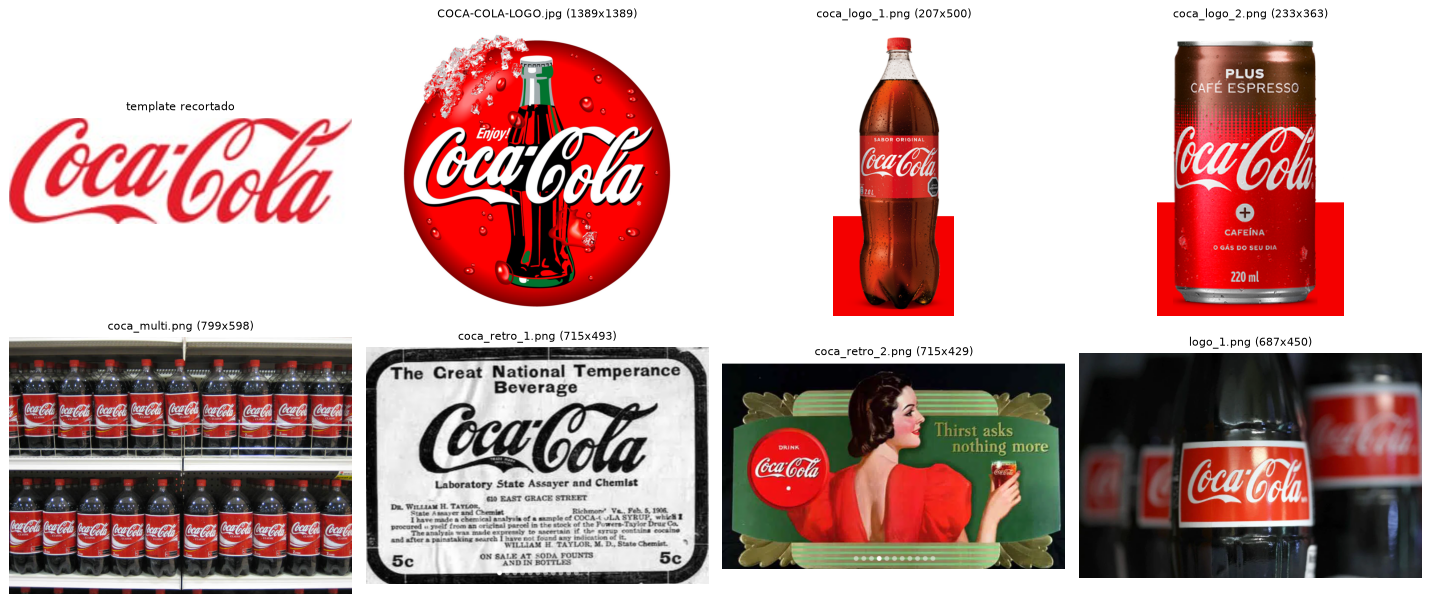

In [4]:
gris_template = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
filas, columnas = np.where(gris_template < 200)          # todo lo que no es fondo blanco
TEMPLATE = template[filas.min():filas.max() + 1, columnas.min():columnas.max() + 1]
print(f'Template recortado: {TEMPLATE.shape[1]}x{TEMPLATE.shape[0]} px (alto/ancho = {TEMPLATE.shape[0] / TEMPLATE.shape[1]:.2f})')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
mostrar(TEMPLATE, 'template recortado', axes[0, 0])
for ax, (nombre, img) in zip(axes.ravel()[1:], imagenes.items()):
    mostrar(img, f'{nombre} ({img.shape[1]}x{img.shape[0]})', ax)
fig.tight_layout()
plt.show()

Mirando las imágenes aparecen las dificultades que tiene que resolver el algoritmo:

- **Contraste invertido.** El template es rojo sobre blanco, pero en `COCA-COLA-LOGO.jpg`, en las botellas (`coca_logo_1.png` y `coca_multi.png`), en la lata (`coca_logo_2.png`), en `coca_retro_2.png` y en `logo_1.png` el logo es blanco sobre rojo. En `coca_retro_1.png` es negro sobre blanco.
- **Escalas muy distintas.** En `coca_multi.png` cada logo mide unos 80 px de ancho, y en `COCA-COLA-LOGO.jpg` pasa los 1000 px.
- **Deformaciones.** En la lata el logo está impreso sobre un cilindro y se ve comprimido en horizontal; en `COCA-COLA-LOGO.jpg` está un poco inclinado.
- **Varios logos por imagen.** Además de `coca_multi.png`, en `logo_1.png` hay una segunda botella con su logo detrás de la principal.

---
## 2. Método: template matching multiescala

### 2.1 La métrica

Usamos `cv.matchTemplate` con `TM_CCOEFF_NORMED`, la correlación normalizada después de restar la media de la ventana y del template. Tiene dos ventajas para este problema. Al restar la media no le afecta el brillo de cada zona, cosa que sí le pasa a la correlación sin centrar, que tiende a dar valores altos en zonas claras. Y al estar normalizada da un puntaje acotado, comparable entre las posiciones de un mismo mapa (mismo template y misma escala), que podemos mostrar como nivel de confianza. Entre escalas distintas la comparación ya no es tan directa, como vemos en la sección 2.4.

El contraste invertido lo resolvemos tomando el **valor absoluto** de la correlación. Un logo blanco sobre rojo es el negativo del template, y su correlación da cerca de -1 en lugar de +1; con el valor absoluto, los dos casos cuentan igual.

### 2.2 Dos canales: grises y a*

En escala de grises el rojo queda como un gris medio, igual que muchas otras cosas de la escena (sombras, texto, brillos), así que el logo compite con todo eso. Por eso correlacionamos también sobre la componente a* de CIELAB, que mide el eje verde-rojo: el rojo queda muy alto y el blanco y el negro quedan neutros. En ese canal el logo resalta tanto si es rojo sobre blanco como si es blanco sobre rojo. El problema es que en una imagen en blanco y negro, como `coca_retro_1.png`, a* es constante y no aporta nada.

Como cada canal falla donde el otro funciona, usamos como confianza el **promedio** de las dos correlaciones en valor absoluto. En la sección 2.5 comparamos esta elección con usar un solo canal.

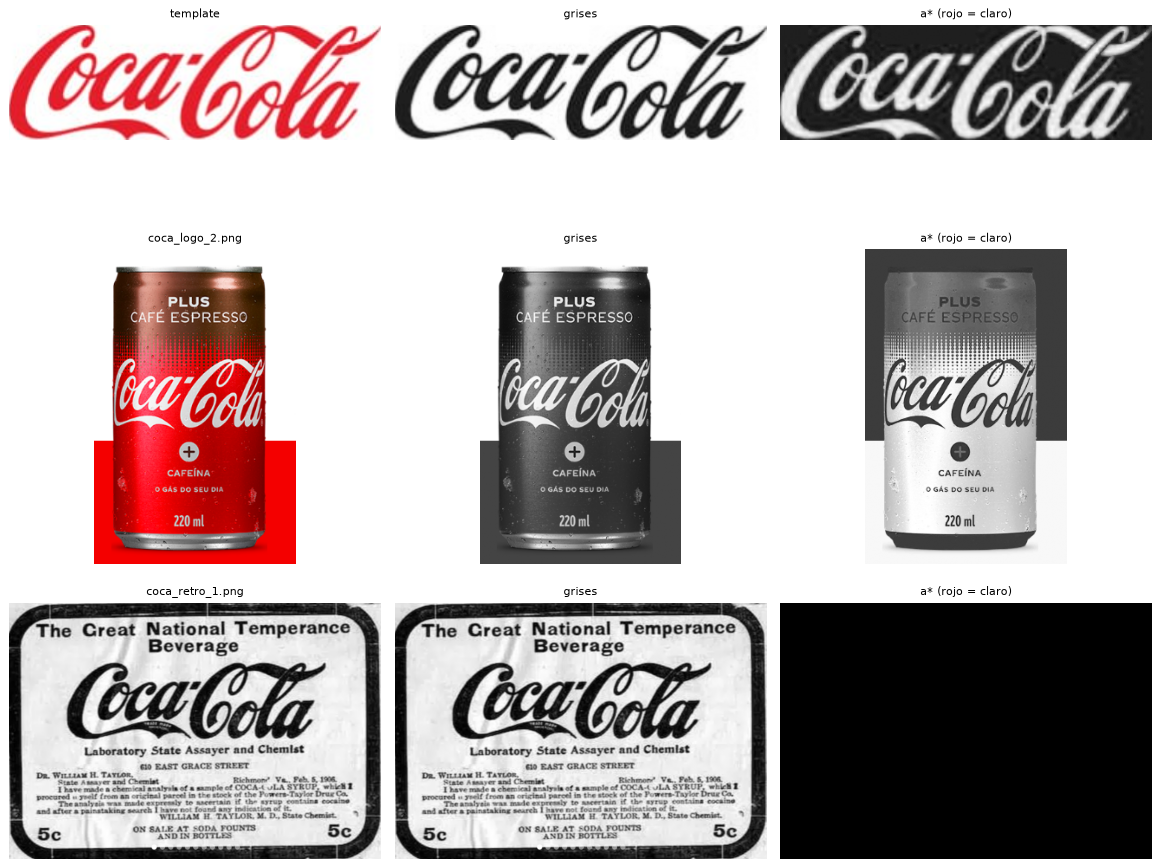

In [5]:
def canales(bgr):
    # Intensidad (grises) y componente a* de CIELAB (eje verde-rojo), en float32 para matchTemplate.
    gris = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    a = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)[:, :, 1]
    return gris.astype(np.float32), a.astype(np.float32)


fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for fila, (titulo, img) in enumerate((('template', TEMPLATE),
                                      ('coca_logo_2.png', imagenes['coca_logo_2.png']),
                                      ('coca_retro_1.png', imagenes['coca_retro_1.png']))):
    gris, a = canales(img)
    mostrar(img, titulo, axes[fila, 0])
    axes[fila, 1].imshow(gris, cmap='gray'); axes[fila, 1].set_title('grises', fontsize=9); axes[fila, 1].axis('off')
    axes[fila, 2].imshow(a, cmap='gray'); axes[fila, 2].set_title('a* (rojo = claro)', fontsize=9); axes[fila, 2].axis('off')
fig.tight_layout()
plt.show()

En la lata se ve bien la diferencia: en grises el logo blanco se confunde con los brillos y con el texto de arriba, mientras que en a* queda como una silueta oscura nítida sobre el rojo. En el aviso en blanco y negro pasa al revés: a* es constante (en la figura se ve como un plano negro) y toda la información está en el canal de grises.

### 2.3 Escalas y relaciones de aspecto

`matchTemplate` sólo es invariante a desplazamientos, así que para encontrar el logo a distintos tamaños armamos una pirámide de tamaños arbitrarios: redimensionamos el template con `cv.resize` a 60 escalas entre 0.1 y 3.5 veces su tamaño (de 37 a 1305 px de ancho), y corremos la búsqueda en cada una. Para achicarlo usamos `INTER_AREA`, que promedia píxeles y evita el aliasing, y para agrandarlo `INTER_LINEAR`.

Descartamos los templates de menos de 60 px de ancho: a ese tamaño el logo mide unos 18 px de alto y el trazo de las letras ya casi no se distingue.

Además de la escala variamos la relación de aspecto. En la lata el logo ocupa unos 175×92 px, con una relación alto/ancho de 0.53, mientras que la del template es 0.31. La lata es un cilindro, y la parte del logo que se curva hacia los costados se ve comprimida en horizontal. Por eso para cada escala probamos el template estirado en vertical por 1, 1.15, 1.3, 1.5 y 1.7.

### 2.4 Cómo comparar escalas distintas

Cada combinación de escala y aspecto da un mapa de confianza distinto, y hay que decidir cuál gana. Tomar directamente el valor más alto es arriesgado: un template chico tiene pocos píxeles y correlaciona alto por casualidad mucho más seguido que uno grande, así que las escalas chicas quedan muy cerca del logo aunque no haya ningún logo donde caen.

Lo que distingue a un logo es que su pico **se destaca del resto del mapa**: el logo da un valor alto en un lugar puntual, y una textura repetida da muchos valores altos parecidos. Por eso a cada mapa lo estandarizamos con su propia media y su desvío, $z = (c - \bar c)/\sigma_c$, y comparamos los picos por $z$. La confianza que mostramos en las cajas sigue siendo la correlación $c$, entre 0 y 1. Es un puntaje de similitud y no una probabilidad de que haya un logo; la decisión de aceptar o no una detección la tomamos con $z$.

De cada mapa guardamos sólo los máximos locales: un píxel es pico si es el máximo de su vecindad, cosa que se calcula fácil comparando el mapa con su dilatación. Así no hace falta guardar cientos de mapas completos.

In [6]:
ESCALAS = np.geomspace(0.1, 3.5, 60)       # ancho del template entre 37 y 1305 px
ASPECTOS = (1.0, 1.15, 1.3, 1.5, 1.7)      # estiramiento vertical relativo al template
ANCHO_MIN = 60                             # más chico que esto, el template pierde el trazo del logo
Z_PISO = 4.0                               # picos que guardamos (los umbrales de detección van más arriba)


def similitud(imagen, template, metrica='ccoeff_abs'):
    # Mapa de similitud entre imagen y template: cuanto más alto, más se parecen.
    if metrica == 'ccoeff_abs':
        return np.abs(cv.matchTemplate(imagen, template, cv.TM_CCOEFF_NORMED))
    if metrica == 'ccoeff':
        return cv.matchTemplate(imagen, template, cv.TM_CCOEFF_NORMED)
    if metrica == 'ccorr':
        return cv.matchTemplate(imagen, template, cv.TM_CCORR_NORMED)
    if metrica == 'sqdiff':
        return 1 - cv.matchTemplate(imagen, template, cv.TM_SQDIFF_NORMED)
    raise ValueError(metrica)


def bordes(bgr):
    # Bordes de Canny sobre la imagen en grises.
    return cv.Canny(cv.cvtColor(bgr, cv.COLOR_BGR2GRAY), 50, 150).astype(np.float32)


def analizar(img, modo='prom', aspectos=ASPECTOS, metrica='ccoeff_abs', con_bordes=False):
    """Template matching multiescala.

    Devuelve los picos (z, confianza, (x, y, w, h)) con z >= Z_PISO, ordenados de mayor a menor z,
    y un resumen por cada escala probada: (ancho, alto, máxima confianza, máximo z, x e y del máximo).
    """
    gris, a = canales(img)
    if con_bordes:                              # se busca sólo sobre los bordes de Canny
        gris, modo = bordes(img), 'gris'
    picos, resumen = [], []
    for s in ESCALAS:
        for aspecto in aspectos:
            w = int(TEMPLATE.shape[1] * s)
            h = int(TEMPLATE.shape[0] * s * aspecto)
            if w < ANCHO_MIN or w > img.shape[1] or h > img.shape[0]:
                continue
            achica = w <= TEMPLATE.shape[1] and h <= TEMPLATE.shape[0]
            t = cv.resize(TEMPLATE, (w, h), interpolation=cv.INTER_AREA if achica else cv.INTER_LINEAR)
            t_gris, t_a = canales(t)
            if con_bordes:
                t_gris = bordes(t)
            c_gris = similitud(gris, t_gris, metrica)
            if modo == 'gris':
                confianza = c_gris
            else:
                c_a = similitud(a, t_a, metrica)
                confianza = c_a if modo == 'a' else (c_gris + c_a) / 2
            if confianza.std() == 0:            # canal sin información (por ejemplo, a* en blanco y negro)
                continue
            z = (confianza - confianza.mean()) / confianza.std()
            k = max(3, int(min(w, h) * 0.5)) | 1
            es_pico = (z >= Z_PISO) & (z == cv.dilate(z, np.ones((k, k), np.uint8)))
            for y, x in zip(*np.where(es_pico)):
                picos.append((float(z[y, x]), float(confianza[y, x]), (int(x), int(y), w, h)))
            y_max, x_max = np.unravel_index(np.argmax(z), z.shape)
            resumen.append((w, h, float(confianza.max()), float(z.max()), int(x_max), int(y_max)))
    picos.sort(reverse=True)
    return picos, resumen


def mejor_del_resumen(resumen):
    # La detección de mayor z entre todas las escalas, aunque no llegue a Z_PISO.
    w, h, confianza, z, x, y = max(resumen, key=lambda fila: fila[3])
    return z, confianza, (x, y, w, h)

Corremos el análisis una sola vez para las siete imágenes y los tres ítems reutilizan el resultado. Tarda menos de un minuto, casi todo en `COCA-COLA-LOGO.jpg`, que es la más grande.

In [7]:
PICOS, RESUMEN = {}, {}
for nombre, img in imagenes.items():
    PICOS[nombre], RESUMEN[nombre] = analizar(img)
    print(f'{nombre:20s} {len(RESUMEN[nombre]):3d} escalas probadas, {len(PICOS[nombre]):4d} picos con z >= {Z_PISO}')

COCA-COLA-LOGO.jpg   260 escalas probadas, 4047 picos con z >= 4.0


coca_logo_1.png      105 escalas probadas,  304 picos con z >= 4.0


coca_logo_2.png      115 escalas probadas,  141 picos con z >= 4.0


coca_multi.png       215 escalas probadas, 1239 picos con z >= 4.0


coca_retro_1.png     210 escalas probadas,  621 picos con z >= 4.0


coca_retro_2.png     210 escalas probadas,  853 picos con z >= 4.0


logo_1.png           205 escalas probadas,  709 picos con z >= 4.0


Para ver el problema de las escalas chicas, graficamos para la lata la mayor confianza y el mayor $z$ que se obtienen con cada ancho de template.

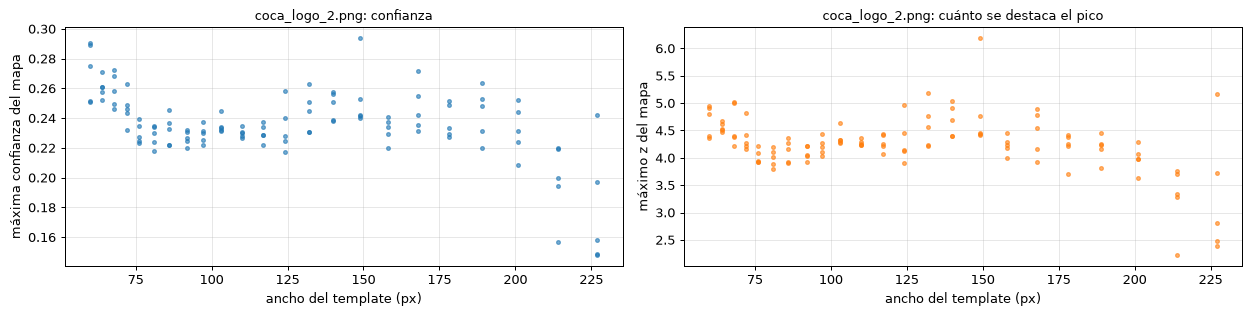

Logo                     : caja (13, 127, 149, 78), confianza 0.294, z 6.2
Mejor rival por confianza: caja (142, 200, 60, 18), confianza 0.291, z 4.9
Mejor rival por z        : caja (75, 6, 132, 69), confianza 0.263, z 5.2


In [8]:
res = np.array(RESUMEN['coca_logo_2.png'])
fig, (ax_c, ax_z) = plt.subplots(1, 2, figsize=(14, 3.6))
ax_c.plot(res[:, 0], res[:, 2], '.', alpha=0.6)
ax_c.set_xlabel('ancho del template (px)'); ax_c.set_ylabel('máxima confianza del mapa')
ax_c.set_title('coca_logo_2.png: confianza', fontsize=10); ax_c.grid(alpha=0.3)
ax_z.plot(res[:, 0], res[:, 3], '.', color='C1', alpha=0.6)
ax_z.set_xlabel('ancho del template (px)'); ax_z.set_ylabel('máximo z del mapa')
ax_z.set_title('coca_logo_2.png: cuánto se destaca el pico', fontsize=10); ax_z.grid(alpha=0.3)
fig.tight_layout()
plt.show()

picos = PICOS['coca_logo_2.png']
logo = picos[0]
rivales = [p for p in picos if iou(p[2], logo[2]) < 0.1]          # picos que no tocan al logo
rival_conf = max(rivales, key=lambda p: p[1])
rival_z = max(rivales, key=lambda p: p[0])
print(f'Logo                     : caja {logo[2]}, confianza {logo[1]:.3f}, z {logo[0]:.1f}')
print(f'Mejor rival por confianza: caja {rival_conf[2]}, confianza {rival_conf[1]:.3f}, z {rival_conf[0]:.1f}')
print(f'Mejor rival por z        : caja {rival_z[2]}, confianza {rival_z[1]:.3f}, z {rival_z[0]:.1f}')

En la lata se ve bien el problema. Por confianza, el logo (0.294, con un template de 149 px) le gana por muy poco a un template de 60 px que cae en otra zona de la lata (0.291): la diferencia está en el tercer decimal. Por $z$, el logo se destaca 6.2 desvíos y el mejor rival, que es el texto "PLUS CAFÉ ESPRESSO", 5.2.

Las dos medidas eligen la misma caja, pero $z$ lo hace con margen. Para el ítem 1 eso no cambia el resultado, porque nos quedamos con el mejor pico de cada imagen. Sí importa en los ítems 2 y 3, donde hay que fijar un único umbral que decida qué es logo y qué no en todas las imágenes.

### 2.5 Qué aporta cada decisión

Para comparar alternativas hace falta saber dónde está cada logo. Anotamos a mano la caja de cada uno mirando las imágenes, y consideramos que una detección es correcta si su intersección sobre unión (IoU) con alguna caja anotada es de al menos 0.5. En `logo_1.png` anotamos los dos logos que se ven enteros, el de la botella principal y el de la botella de atrás. En `coca_multi.png` contamos 18 logos enteros, 9 en cada estante, y además hay tres cortados por los bordes de la foto, que no exigimos que se detecten pero tampoco cuentan como error si aparecen.

In [9]:
FILAS_ARRIBA = [(35, 110), (115, 190), (200, 270), (285, 355), (370, 440), (450, 520), (540, 610), (625, 695), (710, 780)]
FILAS_ABAJO = [(0, 75), (80, 150), (160, 230), (240, 310), (320, 390), (410, 480), (490, 560), (570, 640), (650, 720)]

# Cajas (x, y, ancho, alto) anotadas a mano.
CAJAS_REALES = {
    'COCA-COLA-LOGO.jpg': [(85, 484, 1193, 367)],
    'coca_logo_1.png': [(36, 211, 157, 48)],
    'coca_logo_2.png': [(22, 118, 175, 92)],
    'coca_multi.png': [(x0, 150, x1 - x0, 36) for x0, x1 in FILAS_ARRIBA] +
                      [(x0, 425, x1 - x0, 41) for x0, x1 in FILAS_ABAJO],
    'coca_retro_1.png': [(111, 108, 507, 156)],
    'coca_retro_2.png': [(67, 196, 143, 44)],
    'logo_1.png': [(207, 215, 270, 83), (461, 129, 215, 66)],
}
# Logos cortados por el borde de la imagen: no los exigimos, pero tampoco cuentan como error si aparecen.
CORTADOS = {'coca_multi.png': [(0, 150, 25, 36), (780, 150, 19, 36), (730, 425, 69, 41)]}


def cae_sobre_logo(caja, nombre):
    return max(iou(caja, real) for real in CAJAS_REALES[nombre]) >= 0.5

Primero comparamos la métrica. `matchTemplate` ofrece varias, y además se puede buscar sobre los bordes de Canny en lugar de la imagen. Corremos la búsqueda completa con cada alternativa sobre las siete imágenes y contamos en cuántas la mejor detección cae sobre un logo. Esta celda tarda un par de minutos.

In [10]:
METRICAS = [('CCOEFF_NORMED en valor absoluto', dict()),
            ('CCOEFF_NORMED sin valor absoluto', dict(metrica='ccoeff')),
            ('CCORR_NORMED', dict(metrica='ccorr')),
            ('SQDIFF_NORMED', dict(metrica='sqdiff')),
            ('Canny + CCOEFF_NORMED en valor absoluto', dict(con_bordes=True))]

OTRAS = {}      # picos y resumen de cada alternativa, para reutilizarlos más adelante
print(f'{"métrica":42s} {"aciertos":>8s}  {"confianza del mejor pico":>24s}  fallas')
for etiqueta, opciones in METRICAS:
    if opciones:
        OTRAS[etiqueta] = {n: analizar(img, **opciones) for n, img in imagenes.items()}
        mejores = {n: mejor_del_resumen(r[1]) for n, r in OTRAS[etiqueta].items()}
    else:
        mejores = {n: mejor_del_resumen(RESUMEN[n]) for n in imagenes}     # la elegida, ya calculada
    fallas = [n for n, p in mejores.items() if not cae_sobre_logo(p[2], n)]
    confianzas = [p[1] for p in mejores.values()]
    print(f'{etiqueta:42s} {7 - len(fallas):5d}/7  {min(confianzas):13.2f} a {max(confianzas):.2f}  {", ".join(fallas)}')

métrica                                    aciertos  confianza del mejor pico  fallas
CCOEFF_NORMED en valor absoluto                7/7           0.29 a 0.61  


CCOEFF_NORMED sin valor absoluto               1/7           0.22 a 0.35  COCA-COLA-LOGO.jpg, coca_logo_1.png, coca_logo_2.png, coca_multi.png, coca_retro_2.png, logo_1.png


CCORR_NORMED                                   0/7           0.84 a 0.96  COCA-COLA-LOGO.jpg, coca_logo_1.png, coca_logo_2.png, coca_multi.png, coca_retro_1.png, coca_retro_2.png, logo_1.png


SQDIFF_NORMED                                  0/7           0.50 a 0.92  COCA-COLA-LOGO.jpg, coca_logo_1.png, coca_logo_2.png, coca_multi.png, coca_retro_1.png, coca_retro_2.png, logo_1.png


Canny + CCOEFF_NORMED en valor absoluto        7/7           0.04 a 0.30  


Sólo dos alternativas encuentran el logo en las siete imágenes. Sin el valor absoluto, `CCOEFF_NORMED` acierta únicamente en `coca_retro_1.png`, que es la única imagen donde el logo tiene el mismo contraste que el template (oscuro sobre claro); en las demás está invertido. `CCORR_NORMED` y `SQDIFF_NORMED` no aciertan en ninguna, porque no restan la media y dependen del brillo de cada zona. En el caso de `CCORR_NORMED` el mejor pico queda entre 0.84 y 0.96, pero no coincide con el logo en ninguna imagen. Buscar sobre los bordes de Canny también acierta en las siete, pero con confianzas muy bajas, de 0.04 a 0.30: los bordes son líneas de un píxel de ancho y casi nunca coinciden exactas. En el ítem 3 vamos a ver que, además, con Canny no se puede fijar un umbral para las detecciones múltiples. Por eso nos quedamos con `CCOEFF_NORMED` en valor absoluto sobre la imagen.

Después vemos qué aportan las otras dos decisiones menos obvias: combinar grises con a* y probar varias relaciones de aspecto. Repetimos la búsqueda en las dos imágenes donde se nota la diferencia, la lata y el aviso en blanco y negro.

In [11]:
CONFIGURACIONES = [('sólo grises', 'gris', ASPECTOS),
                   ('sólo a*', 'a', ASPECTOS),
                   ('promedio, sin aspectos', 'prom', (1.0,)),
                   ('promedio, con aspectos', 'prom', ASPECTOS)]
CASOS = ('coca_logo_2.png', 'coca_retro_1.png')

print(f'{"configuración":24s}' + ''.join(f'{n:>22s}' for n in CASOS))
for etiqueta, modo, aspectos in CONFIGURACIONES:
    celdas = []
    for nombre in CASOS:
        picos, _ = analizar(imagenes[nombre], modo, aspectos)
        if not picos:
            celdas.append('sin detección')
        else:
            celdas.append(f'{"logo" if cae_sobre_logo(picos[0][2], nombre) else "falso"} (z {picos[0][0]:.1f})')
    print(f'{etiqueta:24s}' + ''.join(f'{c:>22s}' for c in celdas))

configuración                  coca_logo_2.png      coca_retro_1.png


sólo grises                      falso (z 5.2)         logo (z 12.5)


sólo a*                           logo (z 6.0)         sin detección


promedio, sin aspectos           falso (z 4.9)         logo (z 12.5)


promedio, con aspectos            logo (z 6.2)         logo (z 12.5)


Cada decisión resuelve un caso concreto. Con sólo grises falla la lata: el logo compite con el texto y los brillos de la lata, y gana otra zona. Con sólo a* la lata sale bien, pero en el aviso en blanco y negro no hay ninguna detección, porque a* es constante y la correlación no tiene con qué trabajar. Sin variar el aspecto, el promedio también falla en la lata, porque el template sin estirar no se parece al logo comprimido. Sólo la combinación de los dos canales con las relaciones de aspecto acierta en las dos.

---
## 3. Ítem 1: una detección por imagen

Para el ítem 1 nos quedamos, en cada imagen, con el pico de mayor $z$, y lo comparamos con las cajas anotadas en la sección 2.5.

imagen               confianza      z    IoU
COCA-COLA-LOGO.jpg        0.57    9.1   0.94
coca_logo_1.png           0.45   11.1   0.99
coca_logo_2.png           0.29    6.2   0.65
coca_multi.png            0.55   12.4   0.63
coca_retro_1.png          0.35   12.5   0.96
coca_retro_2.png          0.61   13.6   0.96
logo_1.png                0.42   10.8   0.88


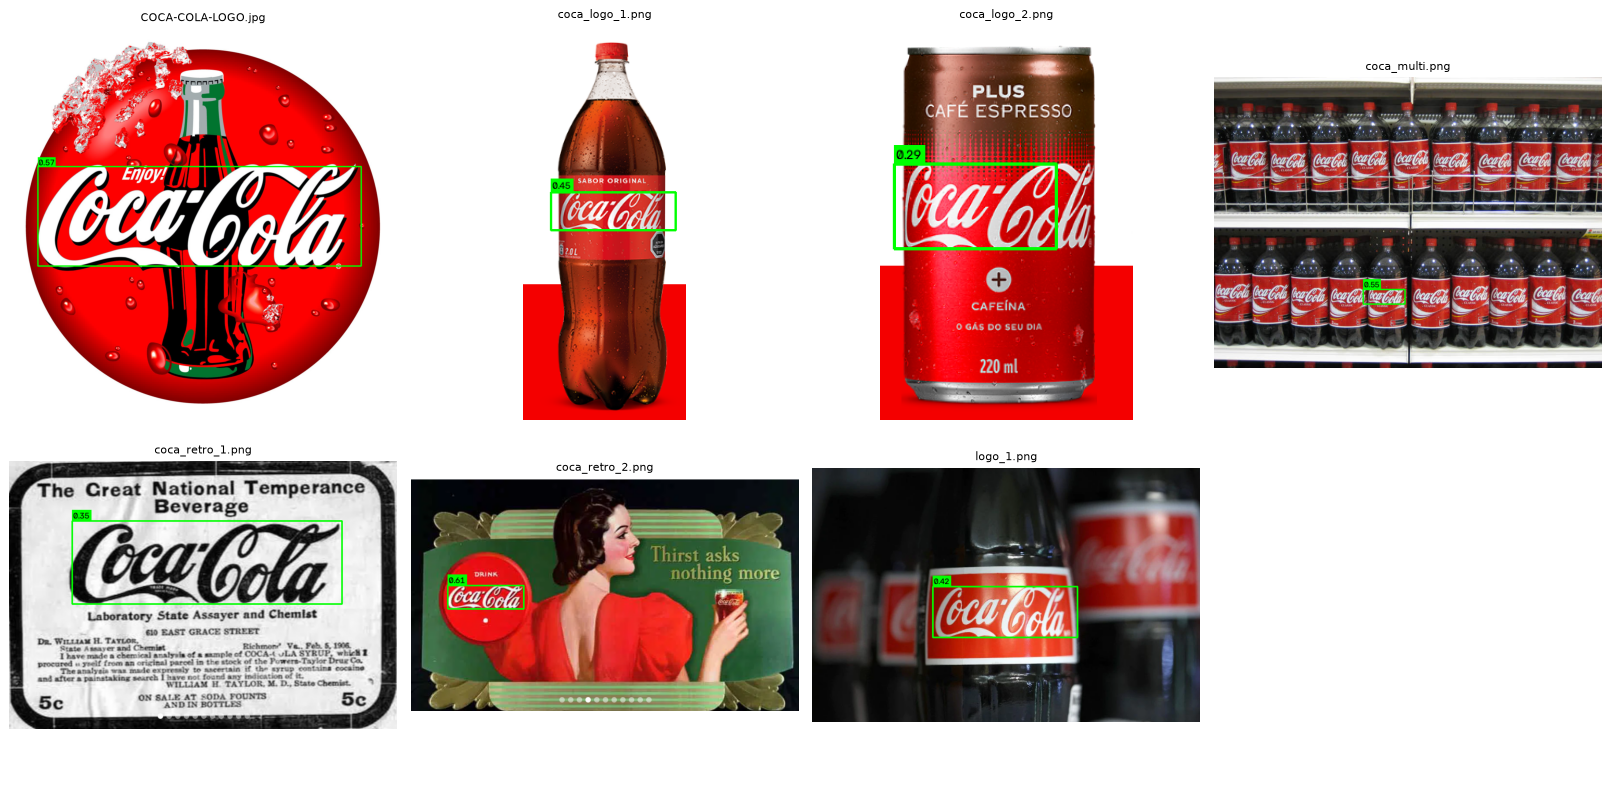

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
print(f'{"imagen":20s} {"confianza":>9s} {"z":>6s} {"IoU":>6s}')
for ax, (nombre, img) in zip(axes.ravel(), imagenes.items()):
    mejor = PICOS[nombre][0]
    acierto = max(iou(mejor[2], caja) for caja in CAJAS_REALES[nombre])
    mostrar(dibujar(img, [mejor]), nombre, ax)
    print(f'{nombre:20s} {mejor[1]:9.2f} {mejor[0]:6.1f} {acierto:6.2f}')
axes.ravel()[-1].axis('off')
fig.tight_layout()
plt.show()

Las siete detecciones caen sobre un logo, con IoU entre 0.63 y 0.99 contra las cajas anotadas, y no hay ningún falso positivo. Algunos detalles:

- En la lata la caja toma "Coca-Co" y deja afuera parte de "la" (IoU 0.65). El final del logo es justo la parte que más se curva con la lata.
- En `coca_multi.png` elige uno de los 18 logos, del estante de abajo. El resto queda para el ítem 2.
- En `logo_1.png` elige el logo de la botella principal, que es el más grande y nítido.
- La confianza va de 0.29 en la lata a 0.61 en el logo redondo de `coca_retro_2.png`. La de `coca_retro_1.png` (0.35) parece baja para un logo tan claro, pero es porque la promediamos con a*, que en esa imagen no aporta nada; su $z$ (12.5) es de los más altos.

---
## 4. Ítem 2: múltiples detecciones en `coca_multi.png`

### 4.1 El algoritmo

Para encontrar varios logos con el mismo template partimos de los picos que ya calculamos y aplicamos tres filtros:

1. **Un umbral sobre $z$.** Un pico es detección si se destaca del resto de su mapa al menos `Z_MIN` desvíos.
2. **Escalas parecidas a la del mejor logo.** Tomamos como referencia el ancho de la detección del ítem 1 y sólo aceptamos picos de entre 0.7 y 1.4 veces ese ancho. Es razonable suponer que los logos de una misma foto aparecen a tamaños parecidos, y esto descarta coincidencias casuales a escalas que no tienen nada que ver.
3. **Supresión de no máximos (NMS).** El mismo logo da picos en varias escalas y aspectos vecinos. Recorremos los candidatos de mayor a menor $z$ y descartamos los que se superponen con IoU mayor a 0.3 con uno ya aceptado.

In [13]:
Z_MIN = 5.8


def nms(candidatos, iou_max=0.3):
    # Los candidatos tienen que venir ordenados de mayor a menor z.
    elegidos = []
    for candidato in candidatos:
        if all(iou(candidato[2], e[2]) <= iou_max for e in elegidos):
            elegidos.append(candidato)
    return elegidos


def detectar_multiples(picos, z_min=Z_MIN, rango=(0.7, 1.4)):
    ancho_ref = picos[0][2][2]
    candidatos = [p for p in picos
                  if p[0] >= z_min and rango[0] * ancho_ref <= p[2][2] <= rango[1] * ancho_ref]
    return nms(candidatos)


def evaluar(detecciones, nombre, iou_min=0.5):
    # Cuenta aciertos (TP), logos no encontrados (FN) y falsos positivos (FP) contra las cajas anotadas.
    reales = CAJAS_REALES[nombre]
    usados, tp, falsos = set(), 0, []
    for d in detecciones:
        libres = [i for i, caja in enumerate(reales) if i not in usados and iou(d[2], caja) >= iou_min]
        if libres:
            usados.add(libres[0])
            tp += 1
        elif not any(iou(d[2], caja) >= iou_min for caja in CORTADOS.get(nombre, [])):
            falsos.append(d)
    return tp, len(reales) - tp, falsos

### 4.2 Validación

En `coca_multi.png` contamos a mano 18 logos enteros, 9 en cada estante, y los anotamos en `CAJAS_REALES`. Hay además tres logos cortados por los bordes de la foto (dos arriba y uno abajo), que no exigimos que se detecten. Corremos el algoritmo y lo comparamos contra esas cajas.

18 detecciones: 18 aciertos, 0 logos sin detectar, 0 falsos positivos
Confianza de las detecciones: entre 0.41 y 0.55
z de las detecciones        : entre 8.7 y 12.4


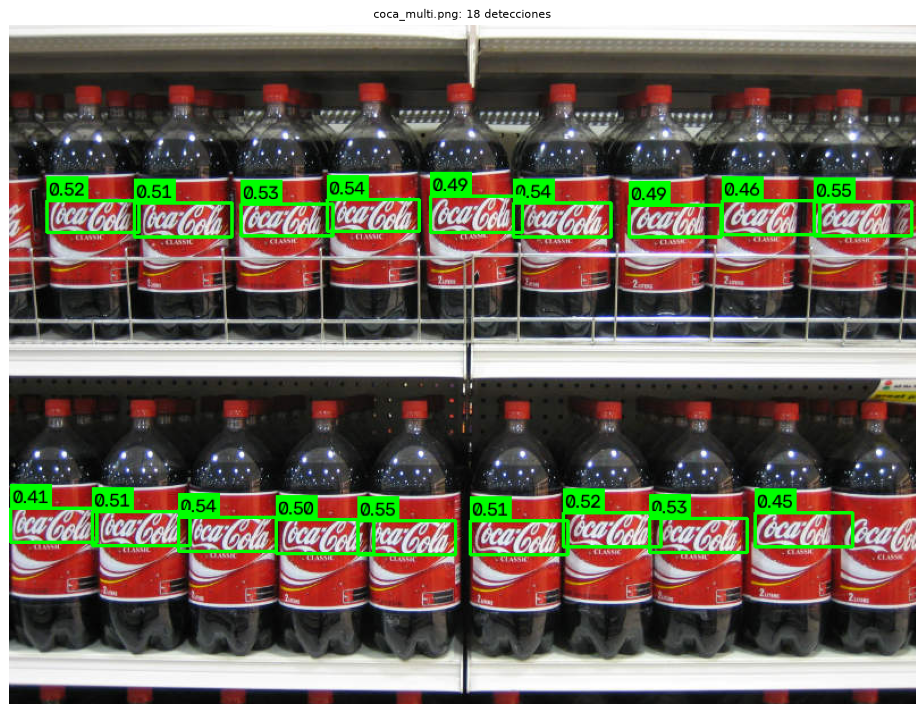

In [14]:
multi = detectar_multiples(PICOS['coca_multi.png'])
tp, fn, falsos = evaluar(multi, 'coca_multi.png')
print(f'{len(multi)} detecciones: {tp} aciertos, {fn} logos sin detectar, {len(falsos)} falsos positivos')
print(f'Confianza de las detecciones: entre {min(d[1] for d in multi):.2f} y {max(d[1] for d in multi):.2f}')
print(f'z de las detecciones        : entre {min(d[0] for d in multi):.1f} y {max(d[0] for d in multi):.1f}')

fig, ax = plt.subplots(figsize=(13, 10))
mostrar(dibujar(imagenes['coca_multi.png'], multi), f'coca_multi.png: {len(multi)} detecciones', ax)
plt.show()

Las 18 detecciones coinciden con los 18 logos anotados: no hay falsos positivos ni logos sin detectar. Los tres logos cortados por los bordes no aparecen, cosa razonable porque el template completo no entra en ellos. La confianza de las detecciones va de 0.41 a 0.55 y el $z$, de 8.7 a 12.4.

Para validar que el resultado no depende de haber acertado justo con el umbral, repetimos la detección con distintos valores de `Z_MIN`:

In [15]:
print(f'{"Z_MIN":>6s} {"aciertos":>9s} {"sin detectar":>13s} {"falsos":>7s}')
for z_min in (4.5, 5.0, 5.5, 5.8, 6.0, 7.0, 8.0, 8.5, 9.0):
    tp, fn, falsos = evaluar(detectar_multiples(PICOS['coca_multi.png'], z_min), 'coca_multi.png')
    print(f'{z_min:6.1f} {tp:9d} {fn:13d} {len(falsos):7d}')

 Z_MIN  aciertos  sin detectar  falsos
   4.5        18             0       8
   5.0        18             0       3
   5.5        18             0       1
   5.8        18             0       0
   6.0        18             0       0
   7.0        18             0       0
   8.0        18             0       0
   8.5        18             0       0
   9.0        17             1       0


En esta imagen cualquier umbral entre 5.8 y 8.5 da el resultado perfecto. Con 5.5 o menos entran falsos positivos, y desde 9 se pierde un logo. El margen es amplio porque acá los logos se destacan mucho: el más débil tiene $z$ 8.7. Elegimos un valor cerca del extremo inferior de ese rango, `Z_MIN = 5.8`, porque en otras imágenes hay logos que se destacan menos, como vamos a ver en el ítem 3.

---
## 5. Ítem 3: generalización a todas las imágenes

Aplicamos a las siete imágenes exactamente el mismo algoritmo del ítem 2, con el mismo `Z_MIN`.

imagen               detecciones  aciertos  sin detectar  falsos
COCA-COLA-LOGO.jpg             1         1             0       0
coca_logo_1.png                1         1             0       0
coca_logo_2.png                1         1             0       0
coca_multi.png                18        18             0       0
coca_retro_1.png               1         1             0       0
coca_retro_2.png               1         1             0       0
logo_1.png                     2         2             0       0
total                                   25             0       0


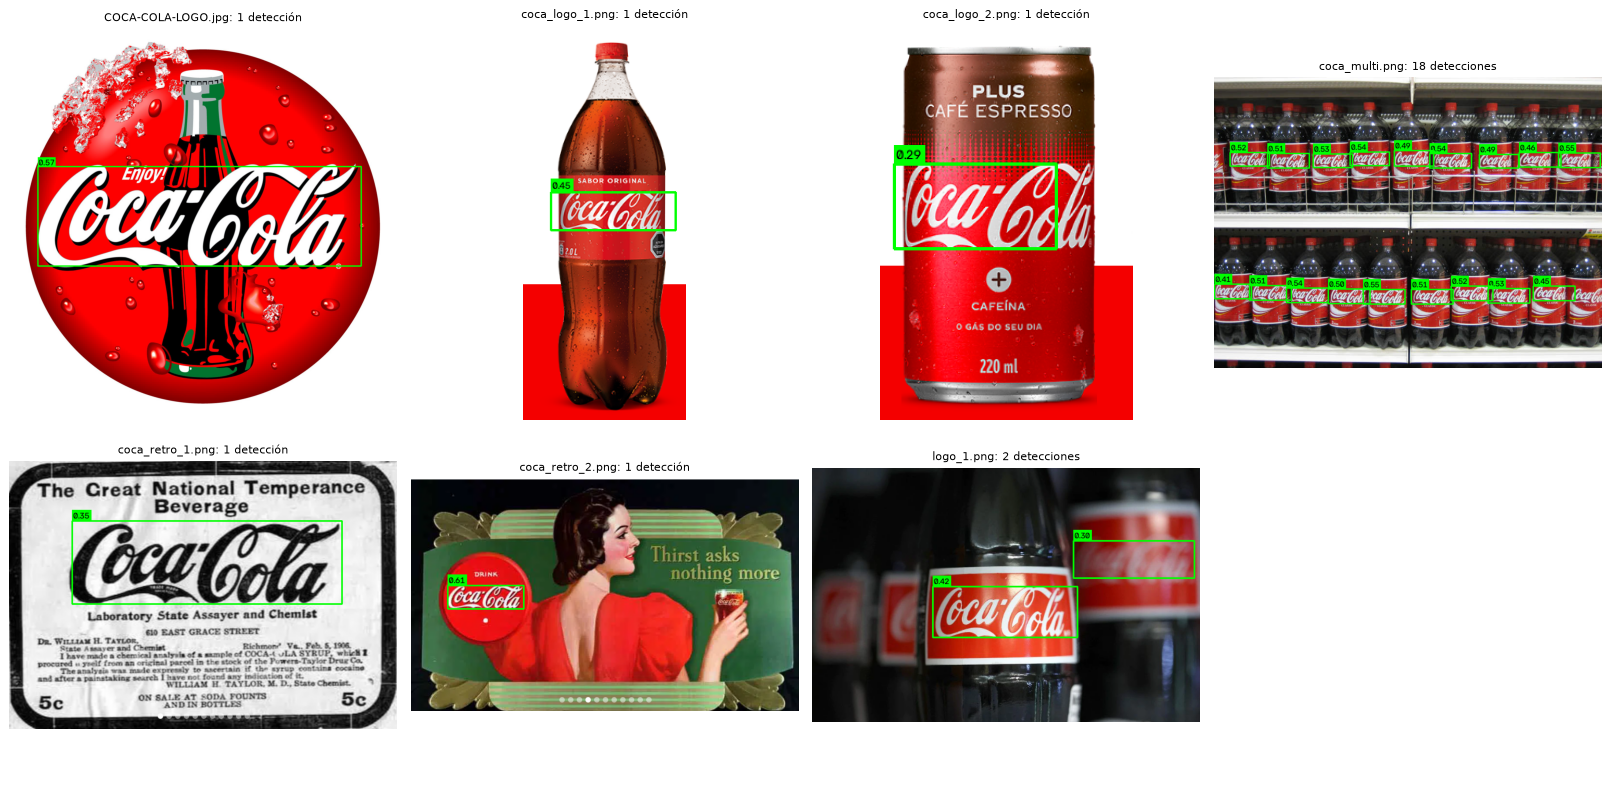

In [16]:
DETECCIONES = {nombre: detectar_multiples(PICOS[nombre]) for nombre in imagenes}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
print(f'{"imagen":20s} {"detecciones":>11s} {"aciertos":>9s} {"sin detectar":>13s} {"falsos":>7s}')
totales = np.zeros(3, int)
for ax, (nombre, img) in zip(axes.ravel(), imagenes.items()):
    tp, fn, falsos = evaluar(DETECCIONES[nombre], nombre)
    totales += (tp, fn, len(falsos))
    n_det = len(DETECCIONES[nombre])
    mostrar(dibujar(img, DETECCIONES[nombre]), f'{nombre}: {n_det} detecci{"ón" if n_det == 1 else "ones"}', ax)
    print(f'{nombre:20s} {len(DETECCIONES[nombre]):11d} {tp:9d} {fn:13d} {len(falsos):7d}')
print(f'{"total":20s} {"":11s} {totales[0]:9d} {totales[1]:13d} {totales[2]:7d}')
axes.ravel()[-1].axis('off')
fig.tight_layout()
plt.show()

Con el mismo algoritmo y el mismo umbral se detectan los 25 logos anotados de las siete imágenes, sin falsos positivos. En las imágenes con un solo logo queda una única caja, y en `logo_1.png` aparecen las dos botellas con el logo entero. La botella desenfocada del costado izquierdo de `logo_1.png` no se detecta: su logo está cortado y muy borroso, y no lo anotamos.

Barremos de nuevo el umbral, ahora sobre las siete imágenes:

In [17]:
print(f'{"Z_MIN":>6s} {"aciertos":>9s} {"sin detectar":>13s} {"falsos":>7s}')
for z_min in (5.0, 5.4, 5.5, 5.6, 5.8, 6.0, 6.1, 6.2, 6.5):
    t = np.zeros(3, int)
    for nombre in imagenes:
        tp, fn, falsos = evaluar(detectar_multiples(PICOS[nombre], z_min), nombre)
        t += (tp, fn, len(falsos))
    print(f'{z_min:6.1f} {t[0]:9d} {t[1]:13d} {t[2]:7d}')

 Z_MIN  aciertos  sin detectar  falsos
   5.0        25             0       7
   5.4        25             0       3
   5.5        25             0       1
   5.6        25             0       0
   5.8        25             0       0
   6.0        25             0       0
   6.1        25             0       0
   6.2        24             1       0
   6.5        24             1       0


Con las siete imágenes el rango útil se achica a 5.6–6.1. El límite de arriba lo pone la lata, que es el logo que menos se destaca ($z$ 6.2), y el de abajo, los picos que no son logo, que llegan hasta 5.5. Nuestro `Z_MIN = 5.8` queda en el medio.

¿Hacía falta usar $z$? Probamos el mismo algoritmo con el umbral puesto directamente sobre la confianza:

In [18]:
def detectar_por_confianza(picos, c_min, rango=(0.7, 1.4)):
    # El mismo algoritmo, pero con el umbral sobre la confianza en lugar de z.
    ancho_ref = picos[0][2][2]
    candidatos = sorted((p for p in picos
                         if p[1] >= c_min and rango[0] * ancho_ref <= p[2][2] <= rango[1] * ancho_ref),
                        key=lambda p: p[1], reverse=True)
    return nms(candidatos)


print(f'{"umbral de confianza":>20s} {"aciertos":>9s} {"sin detectar":>13s} {"falsos":>7s}')
for c_min in (0.26, 0.27, 0.28, 0.285, 0.29, 0.295, 0.30, 0.32):
    t = np.zeros(3, int)
    for nombre in imagenes:
        tp, fn, falsos = evaluar(detectar_por_confianza(PICOS[nombre], c_min), nombre)
        t += (tp, fn, len(falsos))
    print(f'{c_min:20.3f} {t[0]:9d} {t[1]:13d} {t[2]:7d}')

 umbral de confianza  aciertos  sin detectar  falsos
               0.260        25             0       6
               0.270        25             0       4
               0.280        25             0       1
               0.285        25             0       0
               0.290        25             0       0
               0.295        24             1       0
               0.300        24             1       0
               0.320        23             2       0


Con la confianza también se llega al resultado perfecto, pero sólo con umbrales entre 0.285 y 0.29: medio centésimo de margen. Con 0.28 ya entra un falso positivo y con 0.295 se pierde la lata. Un umbral tan justo depende demasiado de estas siete imágenes. Con $z$ el rango útil es bastante más ancho, y el gráfico siguiente muestra por qué.

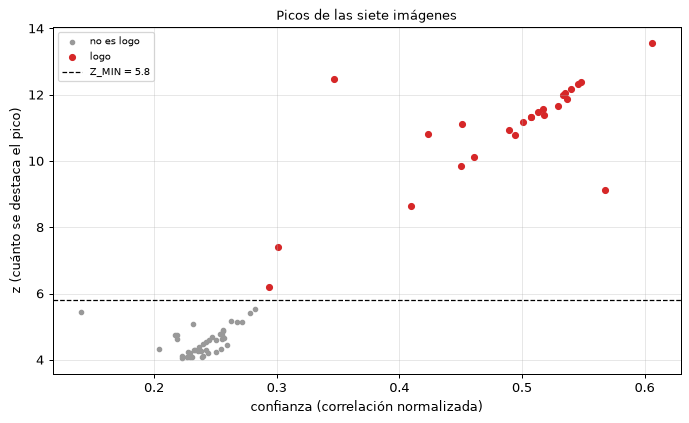

In [19]:
# Confianza y z de todos los picos en escalas cercanas a la del mejor logo, separados en logos y no logos.
fig, ax = plt.subplots(figsize=(9, 5))
for nombre in imagenes:
    ancho_ref = PICOS[nombre][0][2][2]
    cerca = nms([p for p in PICOS[nombre] if 0.7 * ancho_ref <= p[2][2] <= 1.4 * ancho_ref])
    logos = [p for p in cerca if max(iou(p[2], c) for c in CAJAS_REALES[nombre] + CORTADOS.get(nombre, [])) >= 0.5]
    otros = [p for p in cerca if p not in logos]
    ax.scatter([p[1] for p in otros], [p[0] for p in otros], s=12, color='0.6', label='no es logo' if nombre == NOMBRES[0] else None)
    ax.scatter([p[1] for p in logos], [p[0] for p in logos], s=22, color='C3', label='logo' if nombre == NOMBRES[0] else None)
ax.axhline(Z_MIN, color='k', linestyle='--', linewidth=1, label=f'Z_MIN = {Z_MIN}')
ax.set_xlabel('confianza (correlación normalizada)')
ax.set_ylabel('z (cuánto se destaca el pico)')
ax.set_title('Picos de las siete imágenes', fontsize=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

Cada punto es un pico de alguna de las siete imágenes (de los que guardamos, con $z$ ≥ 4), en escalas cercanas a la del mejor logo de su imagen. En el eje de la confianza, los logos más débiles (la lata, con 0.29, y la botella de atrás de `logo_1.png`, con 0.30) quedan pegados a los picos que no son logo, que llegan a 0.28. En el eje de $z$, en cambio, queda un hueco: ningún pico que no sea logo pasa de 5.5 y ningún logo baja de 6.2. Por eso el umbral sobre $z$ es más estable.

Falta una alternativa más. En la sección 2.5 vimos que buscar sobre los bordes de Canny también encuentra el logo en las siete imágenes. ¿Sirve para las detecciones múltiples? Repetimos el barrido de `Z_MIN` con los picos que ya calculamos para esa comparación:

In [20]:
picos_canny = {n: r[0] for n, r in OTRAS['Canny + CCOEFF_NORMED en valor absoluto'].items()}

print(f'{"Z_MIN":>6s} {"aciertos":>9s} {"sin detectar":>13s} {"falsos":>7s}')
for z_min in (5, 6, 7, 8, 9, 10, 11, 12):
    t = np.zeros(3, int)
    for nombre in imagenes:
        tp, fn, falsos = evaluar(detectar_multiples(picos_canny[nombre], z_min), nombre)
        t += (tp, fn, len(falsos))
    print(f'{z_min:6.1f} {t[0]:9d} {t[1]:13d} {t[2]:7d}')

 Z_MIN  aciertos  sin detectar  falsos


   5.0        25             0     354
   6.0        24             1      94
   7.0        24             1      11


   8.0        24             1       5
   9.0        23             2       1
  10.0        23             2       0
  11.0        22             3       0
  12.0        20             5       0


Con Canny no hay ningún umbral que dé el resultado perfecto. Para detectar los 25 logos hay que bajar a 5 y entran 354 falsos positivos, y para no tener falsos hay que subir a 10, donde ya se pierden dos logos. Sobre los bordes, los picos que no son logo se destacan tanto como los de algunos logos y los dos grupos se mezclan. Trabajando sobre la imagen, en cambio, cualquier umbral entre 5.6 y 6.1 da los 25 aciertos sin falsos.

---
## Conclusiones

**Ítem 1.** Con template matching multiescala sobre el promedio de las correlaciones en grises y en a*, probando varias relaciones de aspecto, encontramos el logo en las siete imágenes sin falsos positivos (IoU entre 0.63 y 0.99 contra cajas anotadas a mano). El valor absoluto de la correlación resuelve el contraste invertido. Combinar grises con a* hace que el logo se distinga mejor en las imágenes en color, y el canal de grises es el que permite encontrarlo en la imagen en blanco y negro. Las relaciones de aspecto resuelven la lata, donde el logo se ve comprimido por la forma del envase. De las métricas de `matchTemplate` aplicadas sobre la imagen, sólo `CCOEFF_NORMED` en valor absoluto encuentra el logo en todas: sin el valor absoluto no tolera el contraste invertido, y `CCORR_NORMED` y `SQDIFF_NORMED`, que no restan la media, no aciertan en ninguna.

**Ítem 2.** Para las detecciones múltiples tomamos los máximos locales que se destacan al menos 5.8 desvíos en su mapa, a escalas parecidas a la del mejor logo, y eliminamos los repetidos con NMS. En `coca_multi.png` detecta los 18 logos enteros sin ningún falso positivo, y el resultado se mantiene con cualquier umbral entre 5.8 y 8.5.

**Ítem 3.** El mismo algoritmo, sin cambios, detecta los 25 logos de las siete imágenes sin falsos positivos. Usar $z$ en lugar de la confianza fue lo que permitió un umbral único: con la confianza el rango útil es de medio centésimo, y con $z$ va de 5.6 a 6.1. Buscar sobre los bordes de Canny resuelve el ítem 1, pero no admite ningún umbral que separe los 25 logos de los falsos.

**Limitaciones.** El umbral y los parámetros los ajustamos mirando estas mismas imágenes, así que con imágenes nuevas el margen puede ser menor. El caso más justo es la lata, que queda en $z$ 6.2 con el umbral en 5.8. El método tolera inclinaciones chicas, como la de `COCA-COLA-LOGO.jpg`, pero no rotaciones grandes, y supone que los logos de una misma imagen tienen tamaños parecidos. Los logos cortados por el borde no se detectan, porque el template completo tiene que entrar en la imagen. Por último, la estandarización con $z$ es una corrección empírica: compensa buena parte de las diferencias entre escalas, pero no tiene en cuenta que un mapa con más posiciones tiende a tener máximos más altos por azar.